In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

In [38]:
import pandas as pd

data = fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (20640, 9)

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [39]:
print("Basic stats:\n")
print(df.describe())

print("Null values:")
print(df.isnull().sum())

Basic stats:

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude         Price  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.69230

In [ ]:
X=data.data        
y=data.target   

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)


In [31]:
mean=X_train.mean(axis=0)
std=X_train.std(axis=0)

X_train=(X_train-mean)/std
X_test=(X_test-mean)/std

y_train=y_train.reshape(-1,1)
y_test=y_test.reshape(-1,1)

In [32]:
def predict(X, w, b):
    return (X@w)+b     

def mse_loss(y_pred, y_act):
    m=len(y_act)
    return (1/(2*m))*np.sum((y_pred-y_act)**2)

In [33]:
def gradient_descent(X, y, alpha, lambdax, epochs, mode):
    m,n=X.shape
    w=np.zeros((n,1))
    b=0.0
    loss=[]

    for i in range(epochs):
        y_pred=predict(X, w, b)
        error=y_pred-y

        dw=(X.T @ error)/m
        db=(1/m)*np.sum(error)

        if mode=='l1':
            dw+=(lambdax/m)*np.sign(w)
        elif mode=='l2':
            dw+=(lambdax/m)*w

        w=w-alpha*dw
        b=b-alpha*db

        loss.append(mse_loss(y_pred,y))
    
    return w,b,loss


In [37]:
alpha=0.01
lambdax=0.1
epochs=1000

w1,b1,loss1=gradient_descent(X_train, y_train, alpha, lambdax, epochs, mode='l1')
w2,b2,loss2=gradient_descent(X_train, y_train, alpha, lambdax, epochs, mode='l2')

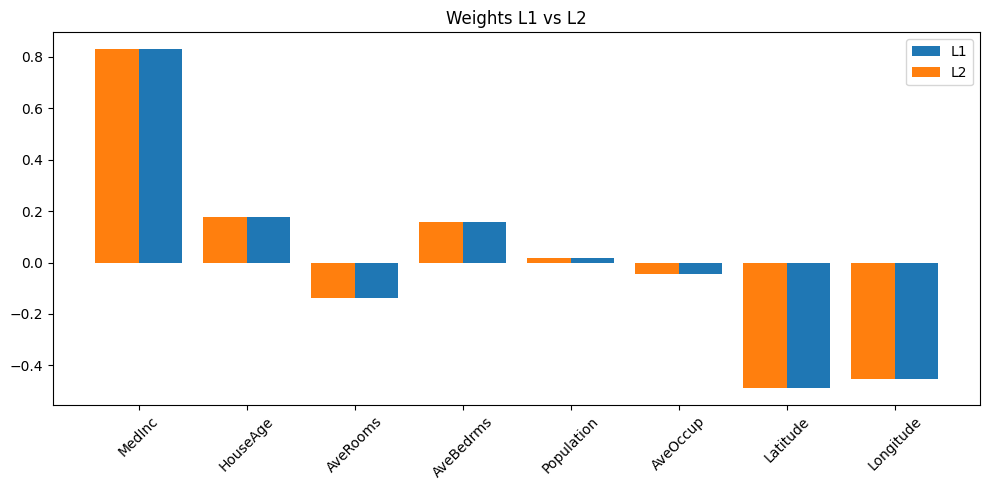

In [42]:
features=data.feature_names
x_pos=np.arange(len(features))

plt.figure(figsize=(10,5))
plt.bar(x_pos+0.2, w1.flatten(), 0.4, label='L1')
plt.bar(x_pos-0.2, w2.flatten(), 0.4, label='L2')
plt.xticks(x_pos, features, rotation=45)
plt.title('Weights L1 vs L2')
plt.legend()
plt.tight_layout()
plt.show()